In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from model import LSTMModel
import warnings
warnings.filterwarnings('ignore')

print("All imports OK!")
print(f"PyTorch version: {torch.__version__}")

All imports OK!
PyTorch version: 2.12.1+cpu


In [2]:
# Load data
columns = ['engine_id', 'cycle', 'setting1', 'setting2', 'setting3'] + \
          [f'sensor{i}' for i in range(1, 22)]

train_df = pd.read_csv('../data/raw/train_FD001.txt',
                       sep='\s+', header=None, names=columns)

# Add RUL
max_cycles = train_df.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.columns = ['engine_id', 'max_cycle']
train_df = train_df.merge(max_cycles, on='engine_id')
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']
train_df.drop(columns=['max_cycle'], inplace=True)

# Cap RUL at 125 (standard practice)
train_df['RUL'] = train_df['RUL'].clip(upper=125)

# Drop low-variance sensors (these carry no signal)
drop_sensors = ['sensor1','sensor5','sensor6','sensor10',
                'sensor16','sensor18','sensor19']
drop_cols = drop_sensors + ['setting1','setting2','setting3']
train_df.drop(columns=drop_cols, inplace=True)

print(f"Shape after cleaning: {train_df.shape}")
print(f"Remaining features: {train_df.columns.tolist()}")

Shape after cleaning: (20631, 17)
Remaining features: ['engine_id', 'cycle', 'sensor2', 'sensor3', 'sensor4', 'sensor7', 'sensor8', 'sensor9', 'sensor11', 'sensor12', 'sensor13', 'sensor14', 'sensor15', 'sensor17', 'sensor20', 'sensor21', 'RUL']


In [3]:
WINDOW_SIZE = 30  # look back 30 cycles

# Select sensor columns only
feature_cols = [c for c in train_df.columns 
                if c not in ['engine_id', 'cycle', 'RUL']]

# Normalize
scaler = MinMaxScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])

def create_sequences(df, window_size):
    X, y = [], []
    for engine_id in df['engine_id'].unique():
        eng_data = df[df['engine_id'] == engine_id]
        sensors = eng_data[feature_cols].values
        rul = eng_data['RUL'].values
        for i in range(len(sensors) - window_size):
            X.append(sensors[i:i+window_size])
            y.append(rul[i+window_size])
    return np.array(X), np.array(y)

X, y = create_sequences(train_df, WINDOW_SIZE)

# Train/val split
split = int(0.8 * len(X))
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")

X_train shape: (14104, 30, 14)
X_val shape:   (3527, 30, 14)


In [4]:
# Convert to tensors
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_val_t   = torch.FloatTensor(X_val)
y_val_t   = torch.FloatTensor(y_val)

# DataLoaders
train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=64, shuffle=True
)

# Model
model = LSTMModel(input_size=X_train.shape[2])
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# Training loop
EPOCHS = 30
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t)
        val_loss = criterion(val_pred, y_val_t)
    
    train_losses.append(np.mean(batch_losses))
    val_losses.append(val_loss.item())
    scheduler.step()
    
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {np.mean(batch_losses):.4f} | Val Loss: {val_loss:.4f}")

print("\nTraining complete!")

Epoch 5/30 | Train Loss: 1875.6176 | Val Loss: 1809.8094
Epoch 10/30 | Train Loss: 826.4700 | Val Loss: 294.4441
Epoch 15/30 | Train Loss: 364.7723 | Val Loss: 260.8757
Epoch 20/30 | Train Loss: 364.9272 | Val Loss: 222.9799
Epoch 25/30 | Train Loss: 332.7060 | Val Loss: 193.7944
Epoch 30/30 | Train Loss: 336.8241 | Val Loss: 217.7120

Training complete!


RMSE: 14.76 cycles
MAE:  11.30 cycles


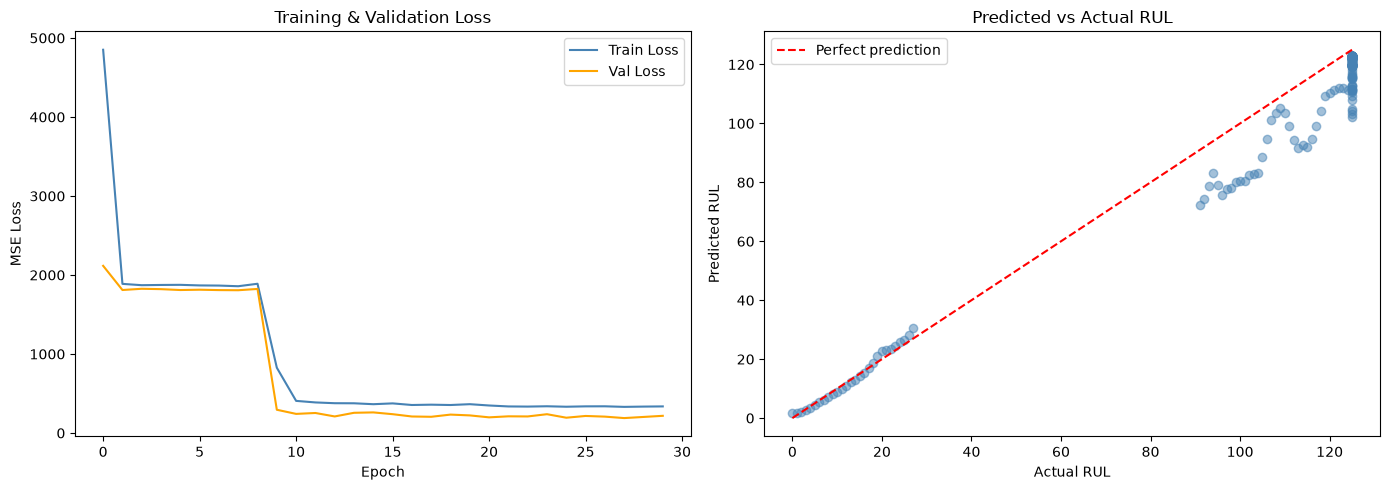

Model saved to models/lstm_rul.pt
Scaler saved to models/scaler.pkl
Config saved to models/model_config.json

Final Results:
   RMSE : 14.76 cycles
   MAE  : 11.30 cycles


In [6]:
import pickle
import json

model.eval()
with torch.no_grad():
    val_pred = model(X_val_t).numpy()
    val_actual = y_val_t.numpy()

rmse = np.sqrt(mean_squared_error(val_actual, val_pred))
mae = mean_absolute_error(val_actual, val_pred)
print(f"RMSE: {rmse:.2f} cycles")
print(f"MAE:  {mae:.2f} cycles")

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train Loss', color='steelblue')
axes[0].plot(val_losses, label='Val Loss', color='orange')
axes[0].set_title('Training & Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

axes[1].scatter(val_actual[:200], val_pred[:200], alpha=0.5, color='steelblue')
axes[1].plot([0,125],[0,125], 'r--', label='Perfect prediction')
axes[1].set_title('Predicted vs Actual RUL')
axes[1].set_xlabel('Actual RUL')
axes[1].set_ylabel('Predicted RUL')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/model_results.png', dpi=150)
plt.show()

# Save model weights
torch.save(model.state_dict(), '../models/lstm_rul.pt')
print("Model saved to models/lstm_rul.pt")

# Save scaler
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler saved to models/scaler.pkl")

# Save model config
model_config = {
    'input_size': X_train.shape[2],
    'hidden_size': 64,
    'num_layers': 2,
    'window_size': WINDOW_SIZE
}
with open('../models/model_config.json', 'w') as f:
    json.dump(model_config, f, indent=4)
print("Config saved to models/model_config.json")

print(f"\nFinal Results:")
print(f"   RMSE : {rmse:.2f} cycles")
print(f"   MAE  : {mae:.2f} cycles")